# Fall Detection — Configuration 02: Real ADLs + Generated (TimeGAN) Falls

This notebook is the **Configuration 02** counterpart to the Configuration 01 baseline.
It follows the same pipeline and the same 1D CNN architecture, so results are comparable
across configurations. Only the parts that differ because of Configuration 02's metadata
(source, generation_type, generation_class, multiplier, and the presence of synthetic
FALL windows) are changed.

**What's new vs Configuration 01:**
* The dataset now mixes `REAL` and `GENERATED` (TimeGAN) samples: **1509 rows** total
  (1014 REAL, 495 GENERATED), all GENERATED rows are `FALL`.
* `subject_id` is only defined for REAL rows; GENERATED rows have `subject_id = NaN` and
  cannot be tied to a subject (or, since `source_sample_id` is 100% missing in this
  export, even to a specific originating REAL fall window).
* The core experimental rule stays the same as Configuration 01: **generalization must be
  measured on REAL, subject-held-out data.** Concretely:
  * The subject-wise TRAIN/VAL/TEST partition is computed **on the REAL subjects only**
    (same procedure as Configuration 01).
  * VALIDATION and TEST contain **REAL samples only**, from held-out subjects.
  * GENERATED samples are added **only to TRAIN** — they augment the training FALL class,
    they never appear in validation or test.

**Pipeline:** Load → sanity checks → subject-wise split (real-only) + generated-to-train
augmentation → preprocessing (fit on TRAIN only) → prepare inputs → 1D CNN → train →
validation curves → REAL-only test evaluation → save.


## 0. Configuration

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Paths (edit these to match your environment)
# ---------------------------------------------------------------------------
CONFIG_NAME   = "02-Real_ADLs+Generated_Falls"
DATA_ROOT     = os.path.join("Classification_Datasets", CONFIG_NAME)
NPY_PATH      = os.path.join(DATA_ROOT, "features.npy")      # <-- adjust filename if different
METADATA_PATH = os.path.join(DATA_ROOT, "metadata.csv")      # <-- adjust filename if different

OUTPUT_DIR = os.path.join("Results", CONFIG_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

# ---------------------------------------------------------------------------
# Split configuration (subject-wise, computed on REAL subjects only)
# ---------------------------------------------------------------------------
N_TEST_SUBJECTS = 2   # REAL subjects held out for the final REAL test set
N_VAL_SUBJECTS  = 2   # REAL subjects held out for validation
# Remaining REAL subjects (10 - 2 - 2 = 6) plus ALL generated samples go to TRAIN

# ---------------------------------------------------------------------------
# Training configuration (kept identical to Configuration 01 for comparability)
# ---------------------------------------------------------------------------
BATCH_SIZE     = 32
MAX_EPOCHS     = 200
LEARNING_RATE  = 1e-3
EARLY_STOP_PATIENCE = 20
LR_PATIENCE    = 8
LR_FACTOR      = 0.5
DROPOUT_RATE   = 0.3

print("Configuration loaded.")
print(f"  Config name : {CONFIG_NAME}")
print(f"  NPY path    : {NPY_PATH}")
print(f"  Metadata    : {METADATA_PATH}")
print(f"  Output dir  : {OUTPUT_DIR}")
print(f"  Seed        : {SEED}")


Configuration loaded.
  Config name : 02-Real_ADLs+Generated_Falls
  NPY path    : Classification_Datasets\02-Real_ADLs+Generated_Falls\features.npy
  Metadata    : Classification_Datasets\02-Real_ADLs+Generated_Falls\metadata.csv
  Output dir  : Results\02-Real_ADLs+Generated_Falls
  Seed        : 42


## 1. Load Dataset

Same alignment check as Configuration 01: `len(X) == len(metadata)`, stop immediately
on mismatch.

In [2]:
import numpy as np
import pandas as pd

BASE_DIR = r"C:\Users\mabideen\Downloads\Data_Augmentation\Three_config_datasets\Model"
DATASET_DIR = os.path.join(BASE_DIR, "Classification_Datasets", "02-Real_ADLs+Generated_Falls")

NPY_PATH = os.path.join(DATASET_DIR, "X_imu_radar.npy")
METADATA_PATH = os.path.join(DATASET_DIR, "metadata.csv")

assert os.path.exists(NPY_PATH), f"NPY file not found: {NPY_PATH}"
assert os.path.exists(METADATA_PATH), f"Metadata file not found: {METADATA_PATH}"

X_all = np.load(NPY_PATH)
metadata = pd.read_csv(METADATA_PATH)

print("Dataset path   :", NPY_PATH)
print("Metadata path  :", METADATA_PATH)
print("Array shape    :", X_all.shape)
print("Array dtype    :", X_all.dtype)
print("Metadata rows  :", len(metadata))
print("Num samples    :", X_all.shape[0])
print("Time frames    :", X_all.shape[1])
print("Num features   :", X_all.shape[2])

if len(X_all) != len(metadata):
    raise ValueError(
        f"Alignment error: len(X)={len(X_all)} != len(metadata)={len(metadata)}. "
        "Stopping — do not proceed with misaligned data."
    )
print("\n[OK] Array and metadata are aligned:", len(X_all), "==", len(metadata))


Dataset path   : C:\Users\mabideen\Downloads\Data_Augmentation\Three_config_datasets\Model\Classification_Datasets\02-Real_ADLs+Generated_Falls\X_imu_radar.npy
Metadata path  : C:\Users\mabideen\Downloads\Data_Augmentation\Three_config_datasets\Model\Classification_Datasets\02-Real_ADLs+Generated_Falls\metadata.csv
Array shape    : (1509, 32, 1137)
Array dtype    : float32
Metadata rows  : 1509
Num samples    : 1509
Time frames    : 32
Num features   : 1137

[OK] Array and metadata are aligned: 1509 == 1509


## 2. Dataset & Metadata Sanity Checks

Adapted to Configuration 02's 19-column metadata: `source` (REAL/GENERATED),
`generation_type`, `generation_class`, `multiplier`, plus everything carried over from
Configuration 01 (`sample_id`, `label`, `subject_id`, fall/window metadata).

In [3]:
print("=" * 70)
print("SANITY CHECKS — Configuration 02: Real ADLs + Generated Falls")
print("=" * 70)

expected_cols = [
    "sample_id", "label", "class_id", "activity_type", "source",
    "generation_type", "generation_class", "source_sample_id", "subject_id",
    "fall_id", "fall_number", "segment_id", "center_time", "window_start",
    "window_end", "original_frame_count", "target_frames", "feature_count",
    "multiplier",
]
missing_cols = [c for c in expected_cols if c not in metadata.columns]
if missing_cols:
    raise ValueError(f"Missing expected metadata columns: {missing_cols}")
print("[OK] All expected metadata columns are present.")

# --- Unique sample_id -------------------------------------------------------
n_unique_ids = metadata["sample_id"].nunique()
assert n_unique_ids == len(metadata), (
    f"sample_id is not unique: {n_unique_ids} unique vs {len(metadata)} rows"
)
print(f"[OK] sample_id is unique ({n_unique_ids} values).")

# --- Valid labels / source values -------------------------------------------
valid_labels = {"FALL", "NON_FALL"}
found_labels = set(metadata["label"].unique())
assert found_labels.issubset(valid_labels), f"Unexpected label values: {found_labels}"

valid_sources = {"REAL", "GENERATED"}
found_sources = set(metadata["source"].unique())
assert found_sources.issubset(valid_sources), f"Unexpected source values: {found_sources}"
print(f"[OK] Labels valid: {found_labels}   Sources valid: {found_sources}")

# --- label / class_id consistency -------------------------------------------
label_to_class = {"NON_FALL": 0, "FALL": 1}
mismatches = metadata[metadata["class_id"] != metadata["label"].map(label_to_class)]
assert len(mismatches) == 0, f"{len(mismatches)} rows where class_id disagrees with label."
print("[OK] class_id is consistent with label for all rows.")

# --- label vs generation_class consistency (generated rows only) -----------
gen_rows = metadata[metadata["source"] == "GENERATED"]
gen_mismatch = gen_rows[gen_rows["label"] != gen_rows["generation_class"]]
assert len(gen_mismatch) == 0, f"{len(gen_mismatch)} GENERATED rows where label != generation_class."
print(f"[OK] label matches generation_class for all {len(gen_rows)} GENERATED rows.")

# --- Class distribution overall ---------------------------------------------
label_counts = metadata["label"].value_counts()
label_pct = metadata["label"].value_counts(normalize=True) * 100
print("\nOverall class distribution:")
for lbl in label_counts.index:
    print(f"  {lbl:10s}: {label_counts[lbl]:5d} ({label_pct[lbl]:5.2f}%)")

# --- REAL vs GENERATED breakdown --------------------------------------------
source_counts = metadata["source"].value_counts()
print("\nREAL vs GENERATED:")
print(source_counts.to_string())

by_source = pd.crosstab(metadata["source"], metadata["label"])
print("\nLabel distribution by source:")
print(by_source)

# GENERATED must be FALL-only (per the inspection report)
assert (gen_rows["label"] == "FALL").all(), "Found a GENERATED row that is not FALL."
print("\n[OK] All GENERATED rows are FALL (no generated NON_FALL samples in this config).")

# --- Subject distribution (REAL rows only — GENERATED rows have no subject) --
real_rows = metadata[metadata["source"] == "REAL"]
subject_counts = real_rows["subject_id"].value_counts().sort_index()
print("\nSubject distribution (REAL rows only):")
print(subject_counts.to_string())

per_subject = pd.crosstab(real_rows["subject_id"], real_rows["label"])
print("\nFALL / NON_FALL per REAL subject:")
print(per_subject)

assert metadata.loc[metadata["source"] == "GENERATED", "subject_id"].isna().all(), (
    "Expected subject_id to be NaN for all GENERATED rows."
)
print("\n[OK] subject_id is NaN for all GENERATED rows, as expected.")

# --- Missing values -----------------------------------------------------------
missing = metadata.isna().sum()
missing = missing[missing > 0]
print("\nMissing values per column:")
print(missing.to_string())
print("\nNote: most of this missingness is structural — subject_id, fall_id, "
      "window timestamps, etc. only exist for REAL rows, and multiplier only exists "
      "for GENERATED rows.")

# --- IMPORTANT CAVEAT: no traceable provenance for generated samples --------
frac_missing_source_id = metadata["source_sample_id"].isna().mean()
print(f"\n[CAVEAT] source_sample_id is missing for {frac_missing_source_id*100:.1f}% of rows "
      "(100% in this export). This means we CANNOT verify which REAL fall window(s) each "
      "GENERATED sample was derived from, so we cannot rule out that some GENERATED FALL "
      "windows in TRAIN were generated from REAL subjects that end up in VALIDATION/TEST. "
      "The methodology below mitigates this at the REAL-data level (VAL/TEST are strictly "
      "REAL-only, held-out subjects) but cannot fully rule out generator-level leakage "
      "given the metadata available.")

# --- NaN / Inf in the feature array ------------------------------------------
n_nan = np.isnan(X_all).sum()
n_inf = np.isinf(X_all).sum()
print(f"\nNaN values in X_all: {n_nan}")
print(f"Inf values in X_all: {n_inf}")
if n_nan > 0 or n_inf > 0:
    raise ValueError(
        f"Data quality issue: {n_nan} NaNs and {n_inf} Infs found in the feature array. "
        "Investigate before proceeding."
    )
print("[OK] No NaN or Inf values in the feature array.")

# --- Shape checks -------------------------------------------------------------
n_samples, n_frames, n_features = X_all.shape
assert (metadata["target_frames"] == n_frames).all(), "target_frames mismatch with array shape"
assert (metadata["feature_count"] == n_features).all(), "feature_count mismatch with array shape"
print(f"[OK] Shape consistent with metadata: samples={n_samples}, frames={n_frames}, features={n_features}")

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Total samples     : {n_samples}  (REAL={len(real_rows)}, GENERATED={len(gen_rows)})")
print(f"Time frames       : {n_frames}")
print(f"Features          : {n_features}")
print(f"FALL              : {label_counts.get('FALL', 0)} ({label_pct.get('FALL', 0):.2f}%)")
print(f"NON_FALL          : {label_counts.get('NON_FALL', 0)} ({label_pct.get('NON_FALL', 0):.2f}%)")
print(f"REAL subjects     : {real_rows['subject_id'].nunique()}")


SANITY CHECKS — Configuration 02: Real ADLs + Generated Falls
[OK] All expected metadata columns are present.
[OK] sample_id is unique (1509 values).
[OK] Labels valid: {'FALL', 'NON_FALL'}   Sources valid: {'GENERATED', 'REAL'}
[OK] class_id is consistent with label for all rows.
[OK] label matches generation_class for all 495 GENERATED rows.

Overall class distribution:
  NON_FALL  :   915 (60.64%)
  FALL      :   594 (39.36%)

REAL vs GENERATED:
source
REAL         1014
GENERATED     495

Label distribution by source:
label      FALL  NON_FALL
source                   
GENERATED   495         0
REAL         99       915

[OK] All GENERATED rows are FALL (no generated NON_FALL samples in this config).

Subject distribution (REAL rows only):
subject_id
1.0     172
2.0      96
3.0     115
4.0      93
5.0      96
6.0      91
7.0      86
8.0      83
9.0      71
10.0    111

FALL / NON_FALL per REAL subject:
label       FALL  NON_FALL
subject_id                
1.0           10       162


## 3. Subject-Wise Split (REAL subjects) + Generated-to-Train Augmentation

**Same rule as Configuration 01, extended for synthetic data:**

* The subject-wise TRAIN/VAL/TEST partition is computed **only over the 10 REAL
  subjects**, using the identical search procedure as Configuration 01 (random subject
  partitions, scored by how close each split's FALL fraction — computed on REAL data —
  is to the REAL-only FALL fraction, rejecting partitions that starve any split of FALL
  samples).
* REAL samples are assigned to TRAIN/VAL/TEST by their subject's assignment, exactly as
  in Configuration 01.
* **All 495 GENERATED samples are appended to TRAIN only.** VALIDATION and TEST remain
  100% REAL, from subjects never seen during training — this is what lets us measure
  whether the generated data helps a model generalize to new, real people, rather than
  just measuring how well the model fits synthetic patterns.

In [4]:
subject_summary = per_subject.copy()
subject_summary["Total"] = subject_summary.sum(axis=1)
subject_summary["FALL_pct"] = 100 * subject_summary.get("FALL", 0) / subject_summary["Total"]
print("Per-REAL-subject candidate summary:")
print(subject_summary)

real_subjects = sorted(real_rows["subject_id"].dropna().unique().tolist())
n_subjects = len(real_subjects)
n_test = N_TEST_SUBJECTS
n_val = N_VAL_SUBJECTS
n_train = n_subjects - n_test - n_val
assert n_train > 0, "Not enough REAL subjects left for training after val/test allocation."

print(f"\nREAL subjects: {n_subjects} total -> train={n_train}, val={n_val}, test={n_test}")

rng = random.Random(SEED)

def fall_fraction(subj_ids, df):
    sub = df[df["subject_id"].isin(subj_ids)]
    if len(sub) == 0:
        return 0.0
    return (sub["label"] == "FALL").mean()

overall_real_fall_frac = (real_rows["label"] == "FALL").mean()

best_partition = None
best_score = None
N_TRIALS = 2000
subjects_list = real_subjects[:]

for _ in range(N_TRIALS):
    shuffled = subjects_list[:]
    rng.shuffle(shuffled)
    test_subj = sorted(shuffled[:n_test])
    val_subj = sorted(shuffled[n_test:n_test + n_val])
    train_subj = sorted(shuffled[n_test + n_val:])

    fracs = [
        fall_fraction(train_subj, real_rows),
        fall_fraction(val_subj, real_rows),
        fall_fraction(test_subj, real_rows),
    ]
    if any(f == 0.0 for f in fracs):
        continue

    score = sum(abs(f - overall_real_fall_frac) for f in fracs)
    if best_score is None or score < best_score:
        best_score = score
        best_partition = (train_subj, val_subj, test_subj)

assert best_partition is not None, "Could not find a REAL-subject partition with FALL samples in every split."
train_subjects, val_subjects, test_subjects = best_partition

print("\nSelected REAL subject-wise split (seed =", SEED, "):")
print("  TRAIN subjects (REAL)     :", train_subjects)
print("  VALIDATION subjects (REAL):", val_subjects)
print("  TEST subjects (REAL)      :", test_subjects)


Per-REAL-subject candidate summary:
label       FALL  NON_FALL  Total   FALL_pct
subject_id                                  
1.0           10       162    172   5.813953
2.0           10        86     96  10.416667
3.0            9       106    115   7.826087
4.0           10        83     93  10.752688
5.0           10        86     96  10.416667
6.0           10        81     91  10.989011
7.0           10        76     86  11.627907
8.0           10        73     83  12.048193
9.0           10        61     71  14.084507
10.0          10       101    111   9.009009

REAL subjects: 10 total -> train=6, val=2, test=2

Selected REAL subject-wise split (seed = 42 ):
  TRAIN subjects (REAL)     : [1.0, 2.0, 5.0, 6.0, 7.0, 9.0]
  VALIDATION subjects (REAL): [4.0, 10.0]
  TEST subjects (REAL)      : [3.0, 8.0]


In [5]:
# --- Disjointness checks (REAL subjects) ------------------------------------
train_set, val_set, test_set = set(train_subjects), set(val_subjects), set(test_subjects)
assert train_set.isdisjoint(val_set), "TRAIN and VALIDATION subjects overlap!"
assert train_set.isdisjoint(test_set), "TRAIN and TEST subjects overlap!"
assert val_set.isdisjoint(test_set), "VALIDATION and TEST subjects overlap!"
print("[OK] TRAIN / VALIDATION / TEST REAL subjects are mutually disjoint.")

# --- Build masks over the FULL metadata --------------------------------------
is_real = (metadata["source"] == "REAL").values
is_generated = (metadata["source"] == "GENERATED").values

real_train_mask = is_real & metadata["subject_id"].isin(train_subjects).values
real_val_mask   = is_real & metadata["subject_id"].isin(val_subjects).values
real_test_mask  = is_real & metadata["subject_id"].isin(test_subjects).values

# GENERATED samples go ONLY to train
train_mask = real_train_mask | is_generated
val_mask   = real_val_mask
test_mask  = real_test_mask

assert not (train_mask & val_mask).any(), "Row assigned to both TRAIN and VAL."
assert not (train_mask & test_mask).any(), "Row assigned to both TRAIN and TEST."
assert not (val_mask & test_mask).any(), "Row assigned to both VAL and TEST."
assert (real_train_mask | real_val_mask | real_test_mask).sum() == is_real.sum(), (
    "Not every REAL row was assigned to a split."
)
assert val_mask.sum() > 0 and (metadata.loc[val_mask, "source"] == "REAL").all(), (
    "VALIDATION must be non-empty and REAL-only."
)
assert test_mask.sum() > 0 and (metadata.loc[test_mask, "source"] == "REAL").all(), (
    "TEST must be non-empty and REAL-only."
)
print("[OK] VALIDATION and TEST are non-empty and contain REAL samples only.")
print(f"[OK] TRAIN contains {real_train_mask.sum()} REAL + {is_generated.sum()} GENERATED samples.")

def split_summary(name, mask):
    sub_meta = metadata[mask]
    n = len(sub_meta)
    n_fall = (sub_meta["label"] == "FALL").sum()
    n_nonfall = (sub_meta["label"] == "NON_FALL").sum()
    n_real = (sub_meta["source"] == "REAL").sum()
    n_gen = (sub_meta["source"] == "GENERATED").sum()
    subj_list = sorted(sub_meta.loc[sub_meta["source"] == "REAL", "subject_id"].unique().tolist())
    print(f"\n{name} split:")
    print(f"  Samples        : {n}  (REAL={n_real}, GENERATED={n_gen})")
    print(f"  FALL           : {n_fall} ({100*n_fall/n:.2f}%)")
    print(f"  NON_FALL       : {n_nonfall} ({100*n_nonfall/n:.2f}%)")
    print(f"  REAL subjects  : {subj_list}")

split_summary("TRAIN", train_mask)
split_summary("VALIDATION", val_mask)
split_summary("TEST", test_mask)

# --- Persist split for reproducibility ---------------------------------------
split_info = {
    "seed": SEED,
    "train_subjects_real": train_subjects,
    "val_subjects_real": val_subjects,
    "test_subjects_real": test_subjects,
    "train_sample_ids": metadata.loc[train_mask, "sample_id"].tolist(),
    "val_sample_ids": metadata.loc[val_mask, "sample_id"].tolist(),
    "test_sample_ids": metadata.loc[test_mask, "sample_id"].tolist(),
    "note": (
        "VALIDATION and TEST are REAL-only, from subjects held out of TRAIN. "
        "All GENERATED (TimeGAN) samples are assigned to TRAIN."
    ),
}
split_path = os.path.join(OUTPUT_DIR, "config02_split.json")
with open(split_path, "w") as f:
    json.dump(split_info, f, indent=2)
print(f"\n[Saved] Split metadata -> {split_path}")


[OK] TRAIN / VALIDATION / TEST REAL subjects are mutually disjoint.
[OK] VALIDATION and TEST are non-empty and contain REAL samples only.
[OK] TRAIN contains 612 REAL + 495 GENERATED samples.

TRAIN split:
  Samples        : 1107  (REAL=612, GENERATED=495)
  FALL           : 555 (50.14%)
  NON_FALL       : 552 (49.86%)
  REAL subjects  : [1.0, 2.0, 5.0, 6.0, 7.0, 9.0]

VALIDATION split:
  Samples        : 204  (REAL=204, GENERATED=0)
  FALL           : 20 (9.80%)
  NON_FALL       : 184 (90.20%)
  REAL subjects  : [4.0, 10.0]

TEST split:
  Samples        : 198  (REAL=198, GENERATED=0)
  FALL           : 19 (9.60%)
  NON_FALL       : 179 (90.40%)
  REAL subjects  : [3.0, 8.0]

[Saved] Split metadata -> Results\02-Real_ADLs+Generated_Falls\config02_split.json


## 4. Preprocessing / Normalization

Identical rule to Configuration 01: fit per-feature mean/std **on TRAIN only** (which now
includes the GENERATED samples) and apply unchanged to VALIDATION and TEST. VAL/TEST are
REAL-only and never influence the fitted statistics.

In [6]:
X_train_raw = X_all[train_mask]
X_val_raw   = X_all[val_mask]
X_test_raw  = X_all[test_mask]

y_train_raw = metadata.loc[train_mask, "label"].values
y_val_raw   = metadata.loc[val_mask, "label"].values
y_test_raw  = metadata.loc[test_mask, "label"].values

print("Raw shapes:")
print("  X_train:", X_train_raw.shape, " X_val:", X_val_raw.shape, " X_test:", X_test_raw.shape)

train_flat_for_stats = X_train_raw.reshape(-1, X_train_raw.shape[-1])
feature_mean = train_flat_for_stats.mean(axis=0)
feature_std = train_flat_for_stats.std(axis=0)
feature_std[feature_std == 0] = 1.0

def normalize(X, mean, std):
    return (X - mean) / std

X_train = normalize(X_train_raw, feature_mean, feature_std)
X_val   = normalize(X_val_raw, feature_mean, feature_std)
X_test  = normalize(X_test_raw, feature_mean, feature_std)

print("\n[OK] Normalization fit on TRAIN only (REAL+GENERATED) and applied to TRAIN/VAL/TEST.")
print("Post-normalization TRAIN mean (~0):", np.round(X_train.mean(), 4))
print("Post-normalization TRAIN std  (~1):", np.round(X_train.std(), 4))

norm_path = os.path.join(OUTPUT_DIR, "config02_normalization.npz")
np.savez(norm_path, mean=feature_mean, std=feature_std)
print(f"[Saved] Normalization parameters -> {norm_path}")


Raw shapes:
  X_train: (1107, 32, 1137)  X_val: (204, 32, 1137)  X_test: (198, 32, 1137)

[OK] Normalization fit on TRAIN only (REAL+GENERATED) and applied to TRAIN/VAL/TEST.
Post-normalization TRAIN mean (~0): 0.0
Post-normalization TRAIN std  (~1): 0.926
[Saved] Normalization parameters -> Results\02-Real_ADLs+Generated_Falls\config02_normalization.npz


## 5. Prepare Model Input

Labels encoded as before (`NON_FALL=0`, `FALL=1`). Because TRAIN now includes the
GENERATED FALL samples, the class balance in TRAIN is far less skewed than in
Configuration 01 (~39% FALL vs ~10% FALL) — we still compute class weights from TRAIN
only, but expect them to be much closer to 1:1.

In [7]:
label_map = {"NON_FALL": 0, "FALL": 1}
y_train = np.array([label_map[l] for l in y_train_raw], dtype=np.int32)
y_val   = np.array([label_map[l] for l in y_val_raw], dtype=np.int32)
y_test  = np.array([label_map[l] for l in y_test_raw], dtype=np.int32)

print("Final input shapes:")
print("  X_train:", X_train.shape, " y_train:", y_train.shape)
print("  X_val  :", X_val.shape,   " y_val  :", y_val.shape)
print("  X_test :", X_test.shape,  " y_test :", y_test.shape)

for name, y in [("TRAIN", y_train), ("VAL", y_val), ("TEST", y_test)]:
    n = len(y)
    n_fall = int(y.sum())
    print(f"\n{name} class distribution: FALL={n_fall} ({100*n_fall/n:.2f}%), "
          f"NON_FALL={n - n_fall} ({100*(n - n_fall)/n:.2f}%)")

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
class_weight_values = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train
)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weight_values)}
print("\nClass weights (computed from TRAIN only):", class_weights)


Final input shapes:
  X_train: (1107, 32, 1137)  y_train: (1107,)
  X_val  : (204, 32, 1137)  y_val  : (204,)
  X_test : (198, 32, 1137)  y_test : (198,)

TRAIN class distribution: FALL=555 (50.14%), NON_FALL=552 (49.86%)

VAL class distribution: FALL=20 (9.80%), NON_FALL=184 (90.20%)

TEST class distribution: FALL=19 (9.60%), NON_FALL=179 (90.40%)

Class weights (computed from TRAIN only): {0: 1.002717391304348, 1: 0.9972972972972973}


## 6. Model: 1D CNN

**Unchanged from Configuration 01**, by design — this experiment is about the effect of
adding generated data, not about architecture differences between configurations.

In [8]:
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers

L2 = 1e-4  # L2 weight regularization strength

def build_model(input_shape, dropout_rate=DROPOUT_RATE, seed=SEED):
    inputs = layers.Input(shape=input_shape, name="input")

    x = layers.Conv1D(64, kernel_size=3, padding="same",
                       kernel_regularizer=regularizers.l2(L2), name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.ReLU(name="relu1")(x)
    x = layers.SpatialDropout1D(dropout_rate * 0.5, name="sdrop1")(x)
    x = layers.MaxPooling1D(pool_size=2, name="pool1")(x)

    x = layers.Conv1D(128, kernel_size=3, padding="same",
                       kernel_regularizer=regularizers.l2(L2), name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.ReLU(name="relu2")(x)
    x = layers.SpatialDropout1D(dropout_rate * 0.5, name="sdrop2")(x)

    x = layers.GlobalAveragePooling1D(name="gap")(x)

    x = layers.Dense(32, activation="relu",
                      kernel_regularizer=regularizers.l2(L2), name="dense1")(x)
    x = layers.Dropout(dropout_rate, seed=seed, name="dropout")(x)

    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)
    return models.Model(inputs=inputs, outputs=outputs, name="fall_cnn_1d")

input_shape = (X_train.shape[1], X_train.shape[2])  # (32, 1137)
print(f"Input shape: {input_shape}")

# Build one throwaway instance just to print architecture / param count.
# Each seed in the ensembling cell below builds and compiles its own fresh copy.
_preview = build_model(input_shape)
_preview.summary()
n_trainable = int(np.sum([np.prod(v.shape) for v in _preview.trainable_weights]))
print(f"\nTrainable parameters (per seed model): {n_trainable:,}")
del _preview


Input shape: (32, 1137)


Model: "fall_cnn_1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 1137)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 32, 64)         │       218,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 32, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sdrop1 (SpatialDropout1D)       │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 16, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 16, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sdrop2 (SpatialDropout1D)       │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,001 (968.75 KB)

 Trainable params: 247,617 (967.25 KB)

 Non-trainable params: 384 (1.50 KB)


Trainable parameters (per seed model): 247,617


## 7. Training

Same optimizer, loss, callbacks, and epoch budget as Configuration 01. Validation still
uses only held-out REAL subjects and never touches normalization fitting or model
selection beyond early-stopping/checkpointing on `val_loss`.

In [9]:
SEEDS = [42, 101, 202, 303, 404]

val_probs_all, test_probs_all, histories_all = [], [], []

for s in SEEDS:
    tf.random.set_seed(s)
    m = build_model(input_shape, seed=s)
    m.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    cb = [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOP_PATIENCE,
            restore_best_weights=True, verbose=0,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=LR_FACTOR, patience=LR_PATIENCE,
            min_lr=1e-6, verbose=0,
        ),
    ]

    h = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=cb,
        verbose=0,
    )

    val_probs_all.append(m.predict(X_val, batch_size=BATCH_SIZE).ravel())
    test_probs_all.append(m.predict(X_test, batch_size=BATCH_SIZE).ravel())
    histories_all.append({k: [float(v) for v in vals] for k, vals in h.history.items()})
    print(f"[seed {s}] done -- best val_loss = {min(h.history['val_loss']):.4f}")

y_val_prob  = np.mean(val_probs_all, axis=0)
y_test_prob = np.mean(test_probs_all, axis=0)
print(f"\n[Ensembling] Averaged predictions across {len(SEEDS)} seeds.")

history_path = os.path.join(OUTPUT_DIR, "config02_history_per_seed.json")
with open(history_path, "w") as f:
    json.dump({str(s): h for s, h in zip(SEEDS, histories_all)}, f, indent=2)
print(f"[Saved] Per-seed training history -> {history_path}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[seed 42] done -- best val_loss = 0.0578
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[seed 101] done -- best val_loss = 0.0312
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[seed 202] done -- best val_loss = 0.0228
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[seed 303] done -- best val_loss = 0.0454
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[seed 404] done -- best val_loss = 0.0408

[Ensembling] Averaged predictions across 5 seeds.
[Saved] Per-seed training history -> Results\02-Real_ADLs+Generated_Falls\config02_history_per_seed.json


In [10]:
# --- Threshold tuning on VALIDATION only (never touches test; uses ensembled y_val_prob) ---
from sklearn.metrics import f1_score, precision_recall_curve

prec_v, rec_v, thresh_v = precision_recall_curve(y_val, y_val_prob)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-9)

# Primary rule: threshold that maximizes F1 on VAL
best_idx = int(np.nanargmax(f1_v[:-1]))          # last PR point has no matching threshold
best_threshold = float(thresh_v[best_idx])

print(f"[Threshold] Max-F1 on VAL: {best_threshold:.4f} "
      f"(VAL precision={prec_v[best_idx]:.3f}, recall={rec_v[best_idx]:.3f}, f1={f1_v[best_idx]:.3f})")

# Optional alternative: highest precision subject to recall >= 0.90.
# Uncomment if you'd rather not miss falls than reduce false alarms.
# recall_floor_mask = rec_v >= 0.90
# if recall_floor_mask.any():
#     alt_idx = int(np.argmax(prec_v[recall_floor_mask]))
#     best_threshold = float(thresh_v[:-1][recall_floor_mask][alt_idx])
#     print(f"[Threshold] Recall-floor(0.90) on VAL: {best_threshold:.4f} "
#           f"(VAL precision={prec_v[recall_floor_mask][alt_idx]:.3f}, "
#           f"recall={rec_v[recall_floor_mask][alt_idx]:.3f})")


[Threshold] Max-F1 on VAL: 0.5442 (VAL precision=1.000, recall=1.000, f1=1.000)


## 8. Training Curves

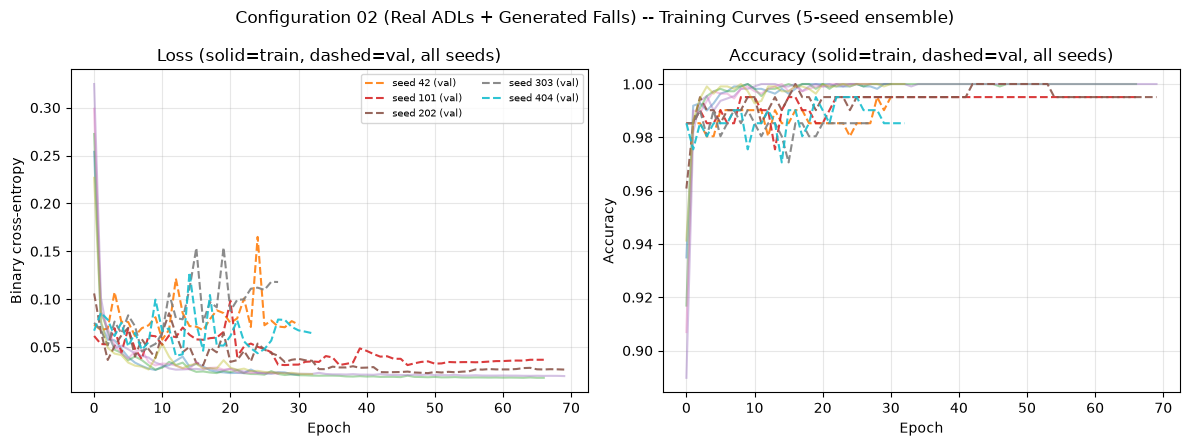

[Saved] Training curves -> Results\02-Real_ADLs+Generated_Falls\config02_training_curves.png


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for s, h in zip(SEEDS, histories_all):
    axes[0].plot(h["loss"], alpha=0.4)
    axes[0].plot(h["val_loss"], alpha=0.9, linestyle="--", label=f"seed {s} (val)")
    axes[1].plot(h["accuracy"], alpha=0.4)
    axes[1].plot(h["val_accuracy"], alpha=0.9, linestyle="--")

axes[0].set_title("Loss (solid=train, dashed=val, all seeds)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)

axes[1].set_title("Accuracy (solid=train, dashed=val, all seeds)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)

fig.suptitle("Configuration 02 (Real ADLs + Generated Falls) -- Training Curves (5-seed ensemble)")
fig.tight_layout()

curves_path = os.path.join(OUTPUT_DIR, "config02_training_curves.png")
fig.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[Saved] Training curves -> {curves_path}")


## 9. Final Evaluation on the REAL Test Set

Evaluated once, on the best checkpoint, on the **REAL-only, held-out-subject** test set —
exactly comparable to the Configuration 01 test evaluation, since both use REAL data from
subjects never seen in training. `FALL = positive class`, `NON_FALL = negative class`.

In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
)

# y_test_prob was already computed by the 5-seed ensembling cell above (averaged probabilities)
y_test_pred = (y_test_prob >= best_threshold).astype(int)

acc = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, pos_label=1, zero_division=0)
recall = recall_score(y_test, y_test_pred, pos_label=1, zero_division=0)   # Sensitivity
f1 = f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)
roc_auc = roc_auc_score(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)

cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])  # rows/cols: [NON_FALL, FALL]
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
balanced_acc = (recall + specificity) / 2

print("=" * 60)
print("FINAL TEST SET EVALUATION -- Configuration 02 (Real ADLs + Generated Falls)")
print("Test set is REAL-only, held-out subjects. Positive class = FALL.")
print("=" * 60)
print(f"Accuracy           : {acc:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"Specificity        : {specificity:.4f}")
print(f"Balanced Accuracy  : {balanced_acc:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"PR-AUC             : {pr_auc:.4f}")

print("\nConfusion matrix (rows=true, cols=pred, order=[NON_FALL, FALL]):")
print(cm)

print("\nClassification report:")
report_str = classification_report(
    y_test, y_test_pred, target_names=["NON_FALL", "FALL"], zero_division=0
)
print(report_str)


FINAL TEST SET EVALUATION -- Configuration 02 (Real ADLs + Generated Falls)
Test set is REAL-only, held-out subjects. Positive class = FALL.
Accuracy           : 0.9798
Precision          : 0.8261
Recall (Sensitivity): 1.0000
F1-score           : 0.9048
Specificity        : 0.9777
Balanced Accuracy  : 0.9888
ROC-AUC            : 0.9929
PR-AUC             : 0.9206

Confusion matrix (rows=true, cols=pred, order=[NON_FALL, FALL]):
[[175   4]
 [  0  19]]

Classification report:
              precision    recall  f1-score   support

    NON_FALL       1.00      0.98      0.99       179
        FALL       0.83      1.00      0.90        19

    accuracy                           0.98       198
   macro avg       0.91      0.99      0.95       198
weighted avg       0.98      0.98      0.98       198



In [13]:
# --- Bootstrap CI on TEST metrics (quantifies how much n=19 falls can wobble) -
rng = np.random.default_rng(SEED)
n_boot = 2000
idx = np.arange(len(y_test))
boot_f1, boot_rec, boot_prec = [], [], []

for _ in range(n_boot):
    sample = rng.choice(idx, size=len(idx), replace=True)
    if y_test[sample].sum() == 0:       # skip resamples with no FALL cases
        continue
    boot_f1.append(f1_score(y_test[sample], y_test_pred[sample], zero_division=0))
    boot_rec.append(recall_score(y_test[sample], y_test_pred[sample], zero_division=0))
    boot_prec.append(precision_score(y_test[sample], y_test_pred[sample], zero_division=0))

def ci(vals):
    return np.percentile(vals, [2.5, 97.5])

print(f"F1 95% CI        : [{ci(boot_f1)[0]:.3f}, {ci(boot_f1)[1]:.3f}]")
print(f"Recall 95% CI    : [{ci(boot_rec)[0]:.3f}, {ci(boot_rec)[1]:.3f}]")
print(f"Precision 95% CI : [{ci(boot_prec)[0]:.3f}, {ci(boot_prec)[1]:.3f}]")

F1 95% CI        : [0.788, 0.980]
Recall 95% CI    : [1.000, 1.000]
Precision 95% CI : [0.650, 0.960]


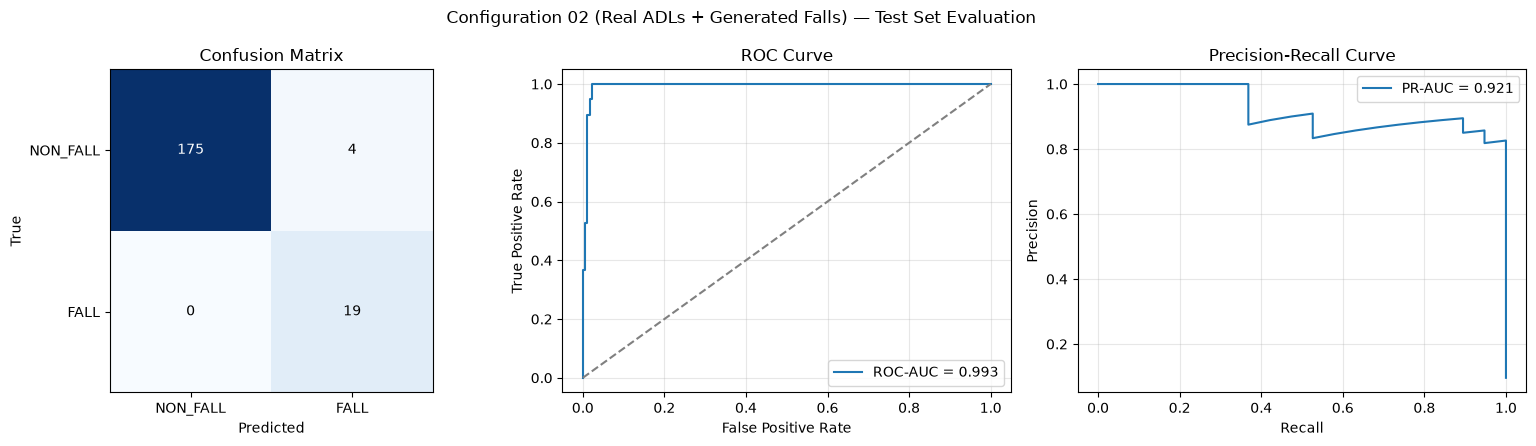

[Saved] Evaluation plots -> Results\02-Real_ADLs+Generated_Falls\config02_evaluation_plots.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["NON_FALL", "FALL"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["NON_FALL", "FALL"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(alpha=0.3)

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_test_prob)
axes[2].plot(rec_curve, prec_curve, label=f"PR-AUC = {pr_auc:.3f}")
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle("Configuration 02 (Real ADLs + Generated Falls) — Test Set Evaluation")
fig.tight_layout()

eval_plot_path = os.path.join(OUTPUT_DIR, "config02_evaluation_plots.png")
fig.savefig(eval_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[Saved] Evaluation plots -> {eval_plot_path}")


## 10. Save Model, Metrics, and Reproducibility Artifacts

In [15]:
cm_path = os.path.join(OUTPUT_DIR, "config02_confusion_matrix.csv")
pd.DataFrame(cm, index=["true_NON_FALL", "true_FALL"],
             columns=["pred_NON_FALL", "pred_FALL"]).to_csv(cm_path)
print(f"[Saved] Confusion matrix -> {cm_path}")

report_path = os.path.join(OUTPUT_DIR, "config02_classification_report.txt")
with open(report_path, "w") as f:
    f.write(report_str)
print(f"[Saved] Classification report -> {report_path}")

cw_path = os.path.join(OUTPUT_DIR, "config02_class_weights.json")
with open(cw_path, "w") as f:
    json.dump(class_weights, f, indent=2)
print(f"[Saved] Class weights -> {cw_path}")

results_row = {
    "config": CONFIG_NAME,
    "n_train": len(y_train),
    "n_train_real": int(real_train_mask.sum()),
    "n_train_generated": int(is_generated.sum()),
    "n_val": len(y_val),
    "n_test": len(y_test),
    "accuracy": acc,
    "precision": precision,
    "recall_sensitivity": recall,
    "f1_score": f1,
    "specificity": specificity,
    "balanced_accuracy": balanced_acc,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc,
    "seeds": str(SEEDS),
}
results_csv_path = os.path.join(OUTPUT_DIR, "config02_results.csv")
pd.DataFrame([results_row]).to_csv(results_csv_path, index=False)
print(f"[Saved] Compact results -> {results_csv_path}")

print("\n" + "=" * 60)
print("All Configuration 02 artifacts saved to:", OUTPUT_DIR)
print("=" * 60)
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", f)

print("\nTo compare against Configuration 01, load both "
      "'config01_results.csv' and 'config02_results.csv' side by side — "
      "both test sets are REAL-only and use disjoint, held-out subjects, "
      "so the metrics are directly comparable.")


[Saved] Confusion matrix -> Results\02-Real_ADLs+Generated_Falls\config02_confusion_matrix.csv
[Saved] Classification report -> Results\02-Real_ADLs+Generated_Falls\config02_classification_report.txt
[Saved] Class weights -> Results\02-Real_ADLs+Generated_Falls\config02_class_weights.json
[Saved] Compact results -> Results\02-Real_ADLs+Generated_Falls\config02_results.csv

All Configuration 02 artifacts saved to: Results\02-Real_ADLs+Generated_Falls
 - config02_class_weights.json
 - config02_classification_report.txt
 - config02_confusion_matrix.csv
 - config02_evaluation_plots.png
 - config02_history_per_seed.json
 - config02_normalization.npz
 - config02_results.csv
 - config02_split.json
 - config02_training_curves.png

To compare against Configuration 01, load both 'config01_results.csv' and 'config02_results.csv' side by side — both test sets are REAL-only and use disjoint, held-out subjects, so the metrics are directly comparable.
